In [106]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from matplotlib.colors import LogNorm
from TDECalculator import TDECalculator

# plt.style.use("plot_style.mplstyle")
# plt.rc('text', usetex=True)


## Call the TDE calculator class

In [107]:
# orbit is the type of orbit of the star
# MBH is the black hole masses, in units of solar masses
# Rp is the pericenter distance, in units of G MBH
# N is the number of steps in the time integration
# a is black hole spin
calc = TDECalculator('MAMS1Msun', orbit="kr", MBH=1e6, Rp=5.0, a=0.52, N=1500)

## Plot the deformed star's equator density

In [108]:
def plot_dist(calc):
    # Use the “equator_sample” method to get POS and dMass.
    # Here we use equator_sample to get an equatorial slice:
    equator_sample = calc.equator_sample(n_phi=3000)
    POS    = equator_sample['POS']        # shape (n_r, 1, n_phi, 3)
    dMass  = equator_sample['dMass']      # shape (n_r, n_phi)

    # flatten x, y, and mass
    x_pos   = POS[...,0].flatten()
    y_pos   = POS[...,1].flatten()
    mass_flat = dMass.flatten()

    # define histogram bin edges
    nbins   = 300
    x_edges = np.linspace(-2, 2, nbins+1)
    y_edges = np.linspace(-3, 3, nbins+1)

    # build 2D mass histogram
    mass_hist, x_edges, y_edges = np.histogram2d(
        x_pos, y_pos,
        bins=[x_edges, y_edges],
        weights=mass_flat
    )

    # convert to surface density
    dx    = x_edges[1] - x_edges[0]
    dy    = y_edges[1] - y_edges[0]
    area  = dx*dy
    density2D = mass_hist / area
    # add tiny non‑constant offset for stable contours
    Xc, Yc = np.meshgrid(
        0.5*(x_edges[:-1]+x_edges[1:]),
        0.5*(y_edges[:-1]+y_edges[1:])
    )
    density2D += 1e-12*(Xc + Yc)

    # prepare interpolation onto a finer grid
    points = np.column_stack((Xc.flatten(), Yc.flatten()))
    values = density2D.T.flatten()
    xi     = np.linspace(Xc.min(), Xc.max(), nbins-1)
    yi     = np.linspace(Yc.min(), Yc.max(), nbins-1)
    XI, YI = np.meshgrid(xi, yi)
    dens_interp = griddata(points, values, (XI, YI), method='linear')
    # normalize for plotting
    dens_interp += dens_interp.max()*1e-8
    dens_interp /= dens_interp.max()

    # — plot! —
    plt.figure(figsize=(8,8))
    levels = np.logspace(
        np.log10(dens_interp[dens_interp>0].min()),
        np.log10(dens_interp.max()),
        100
    )
    cf = plt.contourf(
        XI, YI, dens_interp,
        levels=levels,
        cmap='viridis',
        norm=LogNorm()
    )
    # cf.set_edgecolors('face')

    # arrow pointing “to BH”
    phi0 = calc.Phi_TDE
    plt.arrow(-1.5, 2.25, -0.3*np.cos(phi0), -0.3*np.sin(phi0),
            linewidth=2, head_width=0.1, head_length=0.1, color='white')
    plt.text(-1.5-0.3*np.cos(phi0)+0.1,
            2.25-0.3*np.sin(phi0)+0.1,
            'to BH', color='white', fontsize=14)

    # annotate mass and β
    beta = calc.Rtidal / calc.Rp
    plt.text(1.3, 2.5,  fr'${calc.star_name[4:-4]}\,M_\odot$',
            color='white', fontsize=20)
    plt.text(-1.7, -2.5, fr'$\beta={beta:.2f}$',
            color='white', fontsize=20)

    plt.axis('scaled')
    plt.axis('off')
    plt.colorbar(cf, label='$\\rho/\\rho_c$', ticks=[1e-8, 1e-6, 1e-4, 1e-2, 1])
    plt.show()


## Compute $dM/dE$ and $dM/dT$

In [109]:
def energy_plots(whole_star_sample): 
    # unpack
    dE_rand   = whole_star_sample['dEnergy_random']      # shape (nr-1, N_Omega)
    dE_unp    = whole_star_sample['dEnergy_unperturbed']
    dT_rand   = whole_star_sample['dT_random']
    dT_unp    = whole_star_sample['dT_unperturbed']
    dMass     = whole_star_sample['dMass']               # same shape

    # set up figure
    fig, (axE, axT) = plt.subplots(1, 2, figsize=(12,5))

    # histograms in E
    bins_E = np.linspace(-2, 2, 200)
    axE.hist(dE_rand.flatten(),
            weights=dMass.flatten(),
            bins=bins_E,
            density=True,
            alpha=0.5)
    axE.set_yscale('log')
    axE.set_xlabel(r'$ E / \Delta E$')
    axE.set_ylabel(r'$(\mathrm{d}M/\mathrm{d}E) / (M_\star / \Delta E)$')

    # histograms in T
    bins_T = np.logspace(0, 6, 200)
    axT.hist(dT_rand.flatten(),
            weights=dMass.flatten(),
            bins=bins_T,
            density=True,
            alpha=0.5)
    # overplot T^{-5/3} reference
    axT.plot(bins_T, 10*bins_T**(-5/3), 'k--', label=r'$T^{-5/3}$')
    axT.set_xscale('log')
    axT.set_yscale('log')
    axT.set_xlabel(r'$T / \Delta T$')
    axT.set_ylabel(r'$(\mathrm{d}M/\mathrm{d}T) / (M_\star / \Delta T)$')

    plt.tight_layout()
    plt.show()


## TESTING ##

In [110]:
# N_Omega is the number of angular cells of the grid used to sample the star
calc1 = TDECalculator('MAMS5Msun', orbit="kr", MBH=1e6, Rp=4.9497, a=0.50, N=1500)
whole_star_sample1 = calc1.whole_star_sample(N_Omega=300**2)

calc2 = TDECalculator('MAMS5Msun', orbit="kp", MBH=1e6, Rp=2.96, a=0.50, N=1500)
whole_star_sample2 = calc2.whole_star_sample(N_Omega=300**2)

calc3 = TDECalculator('MAMS5Msun', orbit="kr", MBH=1e6, Rp=6.8, a=0.8, N=1500)
whole_star_sample3 = calc3.whole_star_sample(N_Omega=300**2)

calc4 = TDECalculator('MAMS5Msun', orbit="kp", MBH=1e6, Rp=4.1, a=0.0, N=1500)
whole_star_sample4 = calc4.whole_star_sample(N_Omega=300**2)

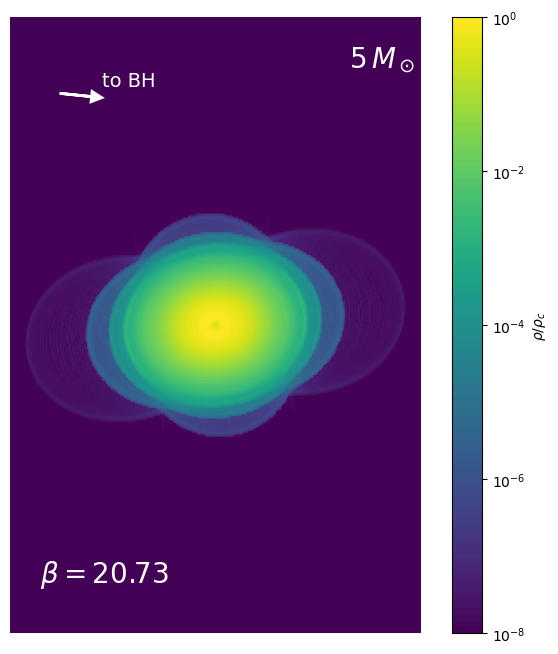

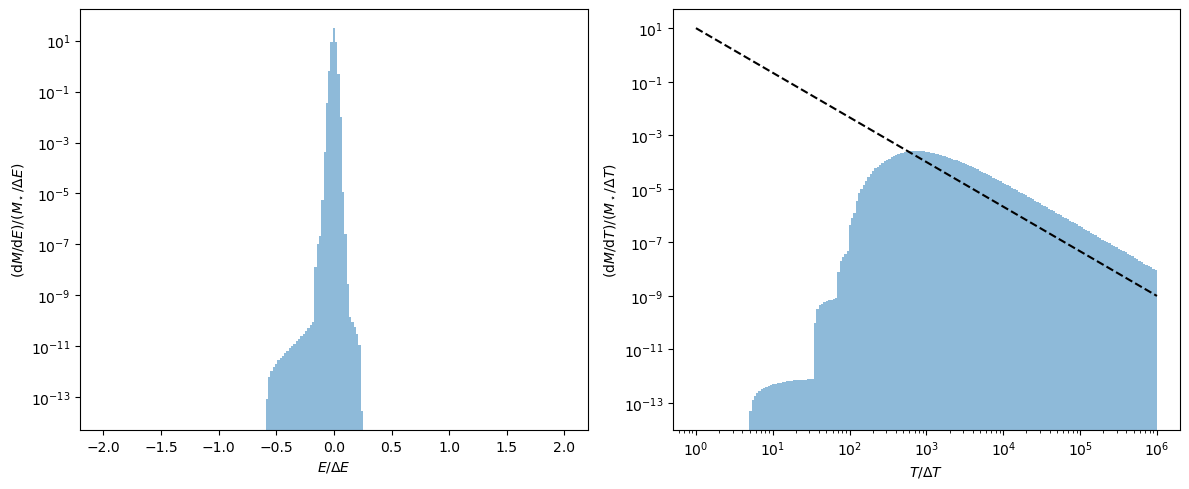

In [111]:
plot_dist(calc1)
energy_plots(whole_star_sample1)

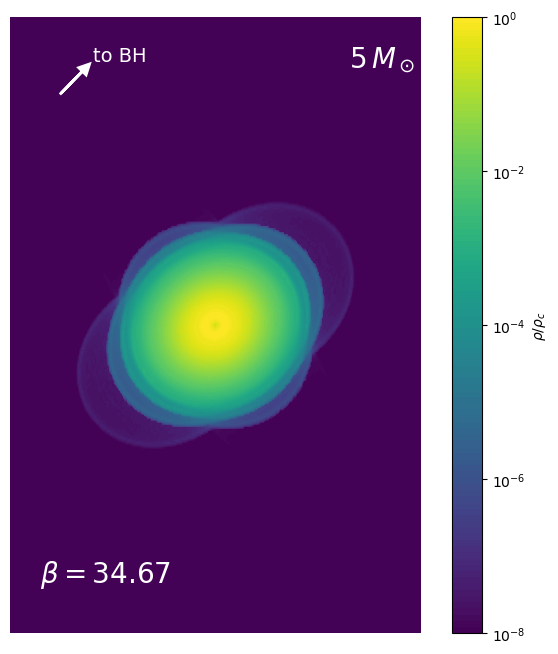

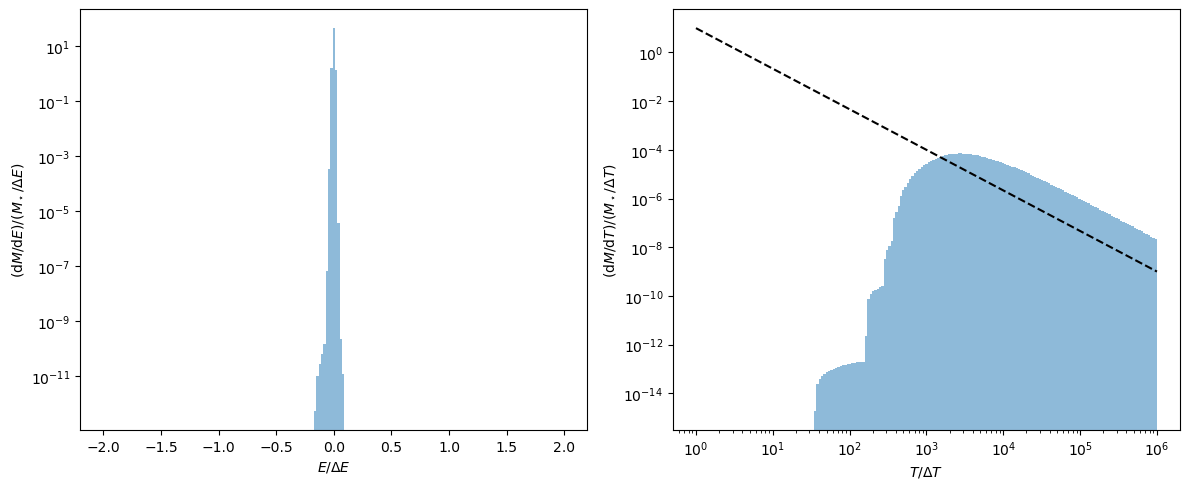

In [112]:
plot_dist(calc2)
energy_plots(whole_star_sample2)

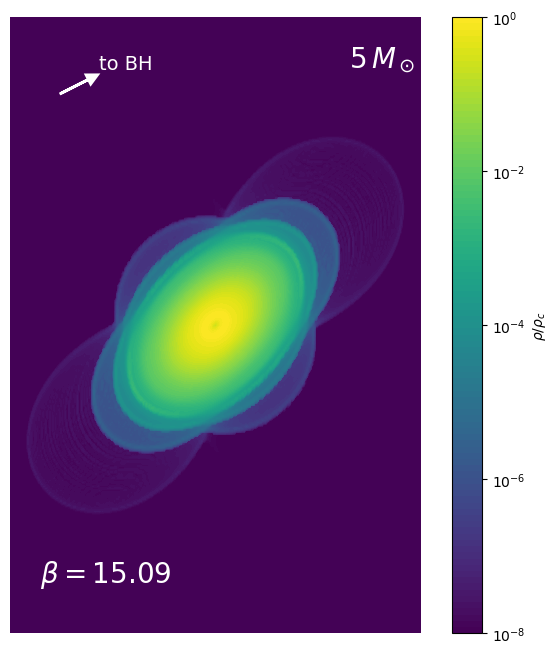

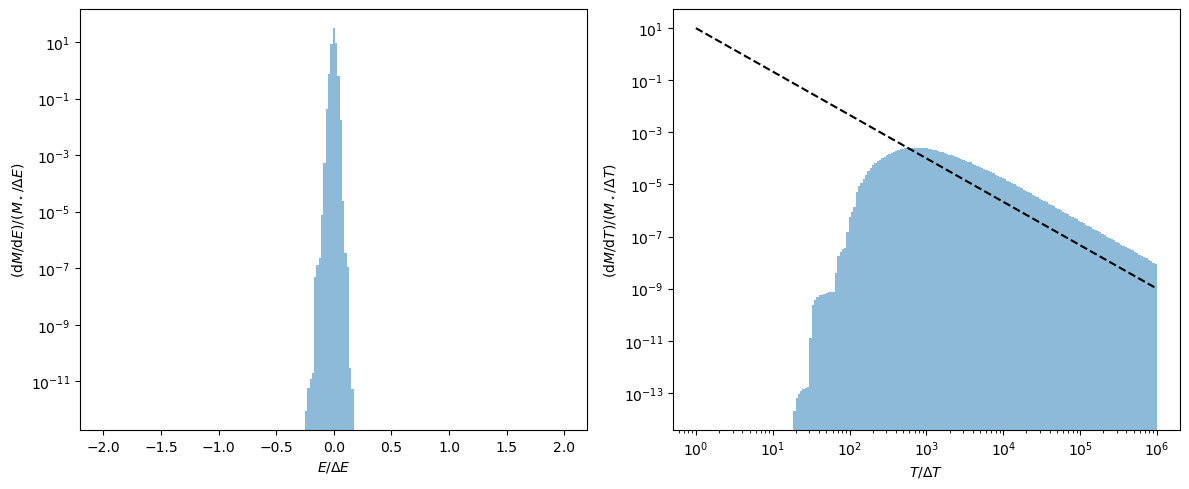

In [113]:
plot_dist(calc3)
energy_plots(whole_star_sample3)

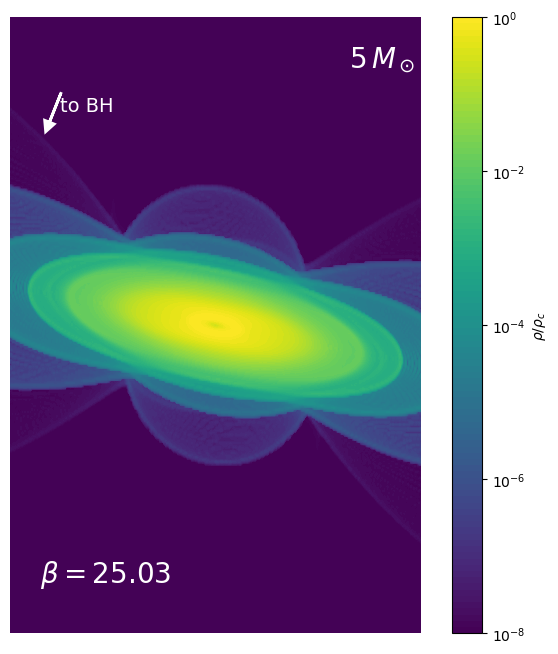

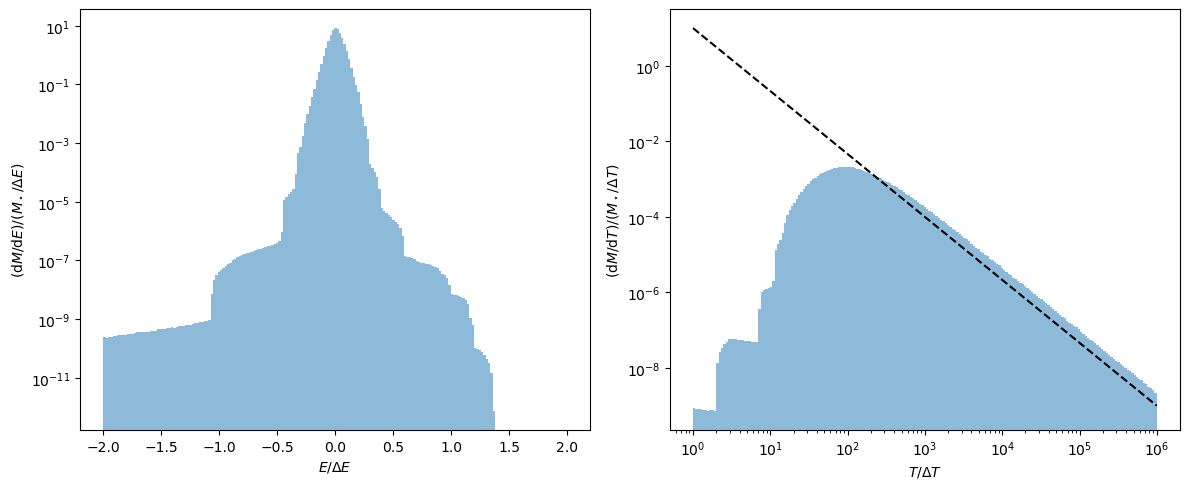

In [114]:
plot_dist(calc4)
energy_plots(whole_star_sample4)

In [115]:
# N_Omega is the number of angular cells of the grid used to sample the star
calc1 = TDECalculator('MAMS8Msun', orbit="kp", MBH=1e6, Rp=7.4, a=0.82, N=1500)
whole_star_sample1 = calc1.whole_star_sample(N_Omega=300**2)

calc2 = TDECalculator('MAMS5Msun', orbit="kp", MBH=1e6, Rp=4.0, a=0.6, N=1500)
whole_star_sample2 = calc2.whole_star_sample(N_Omega=300**2)

calc3 = TDECalculator('MAMS8Msun', orbit="kr", MBH=1e6, Rp=8.7, a=0.82, N=1500)
whole_star_sample3 = calc3.whole_star_sample(N_Omega=300**2)

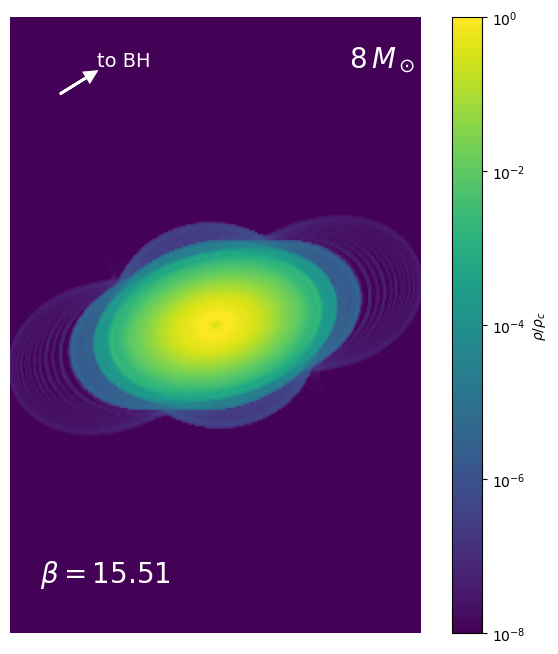

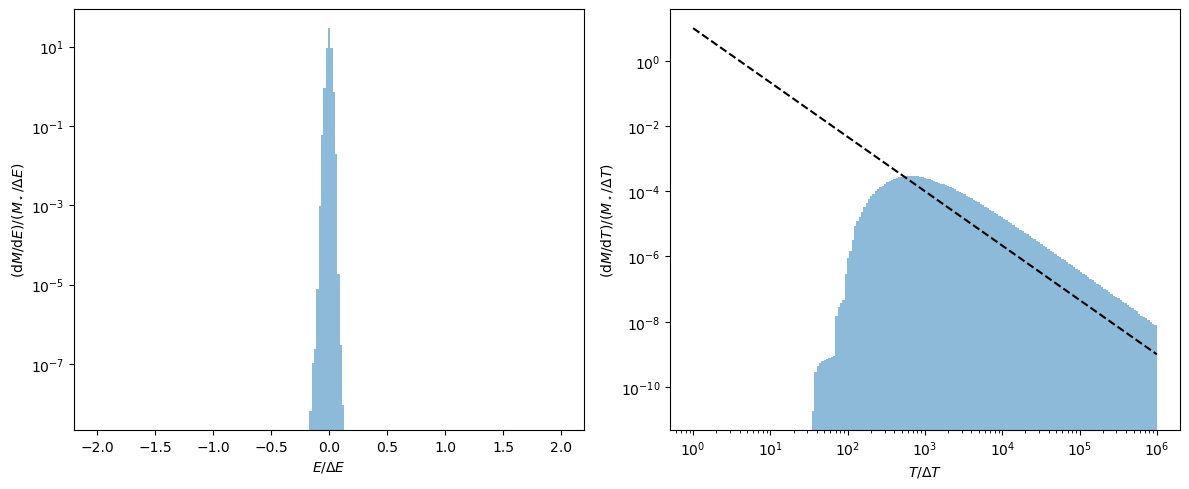

In [116]:
plot_dist(calc1)
energy_plots(whole_star_sample1)

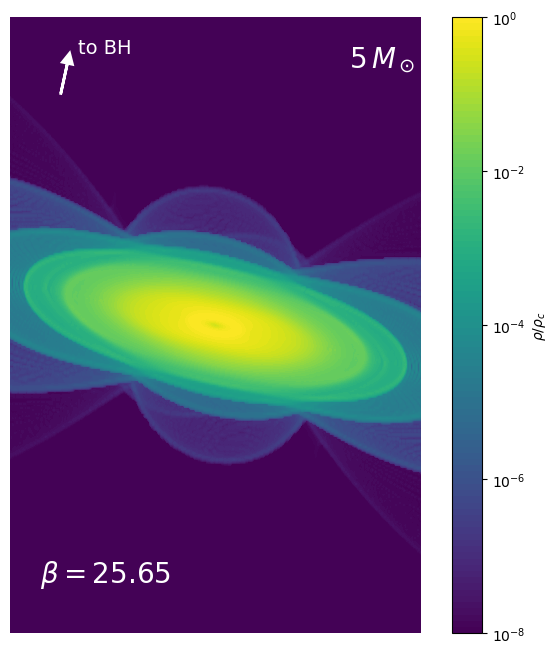

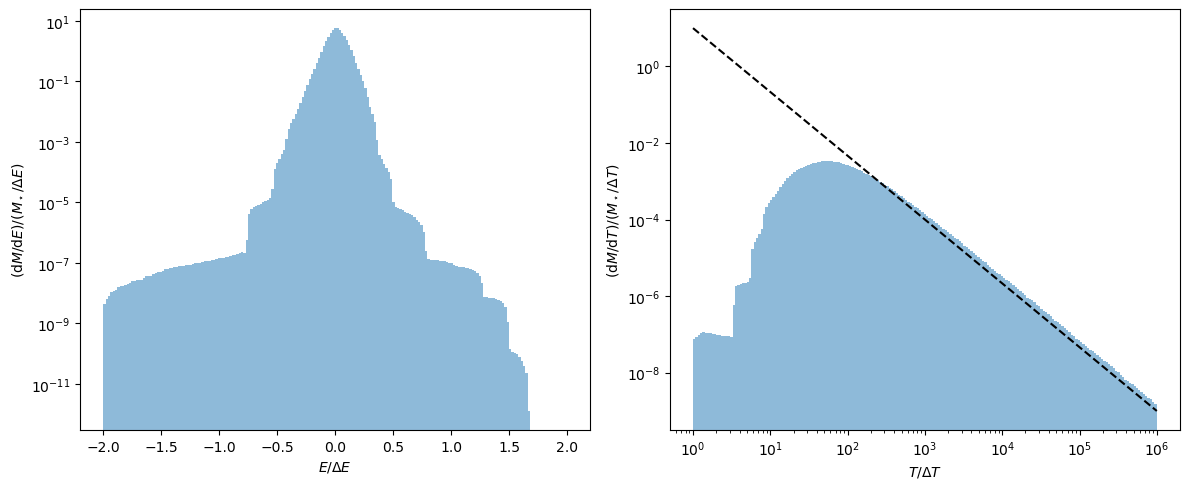

In [117]:
plot_dist(calc2)
energy_plots(whole_star_sample2)

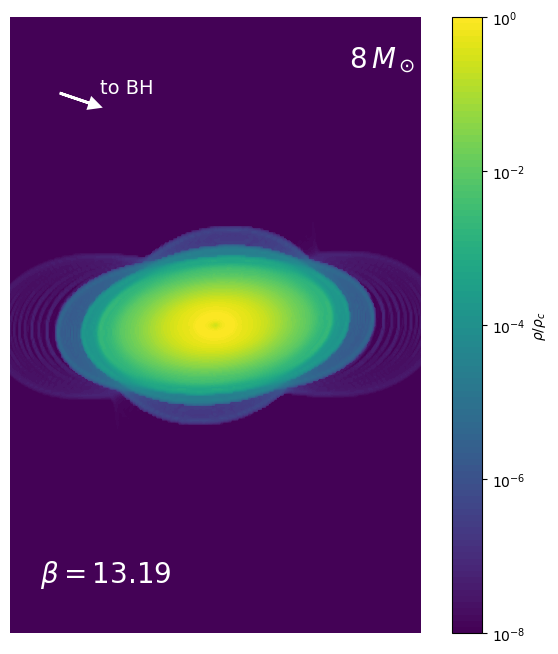

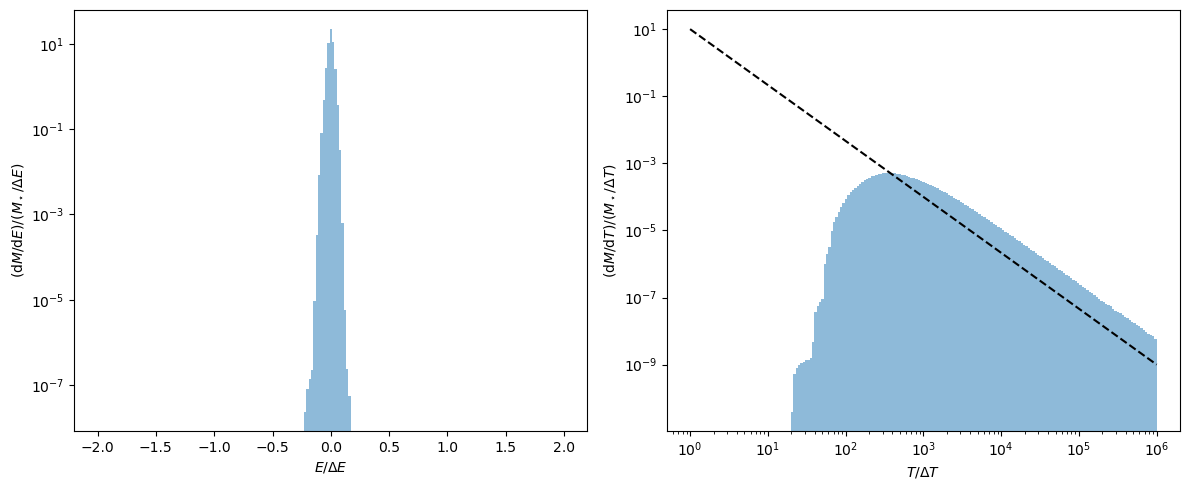

In [118]:
plot_dist(calc3)
energy_plots(whole_star_sample3)

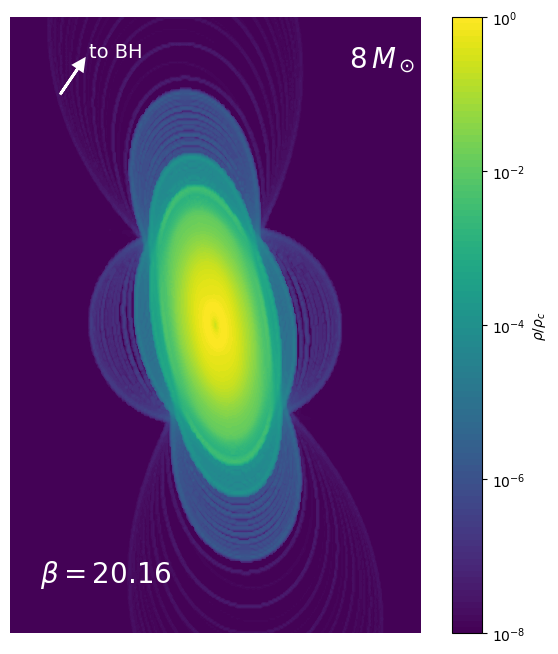

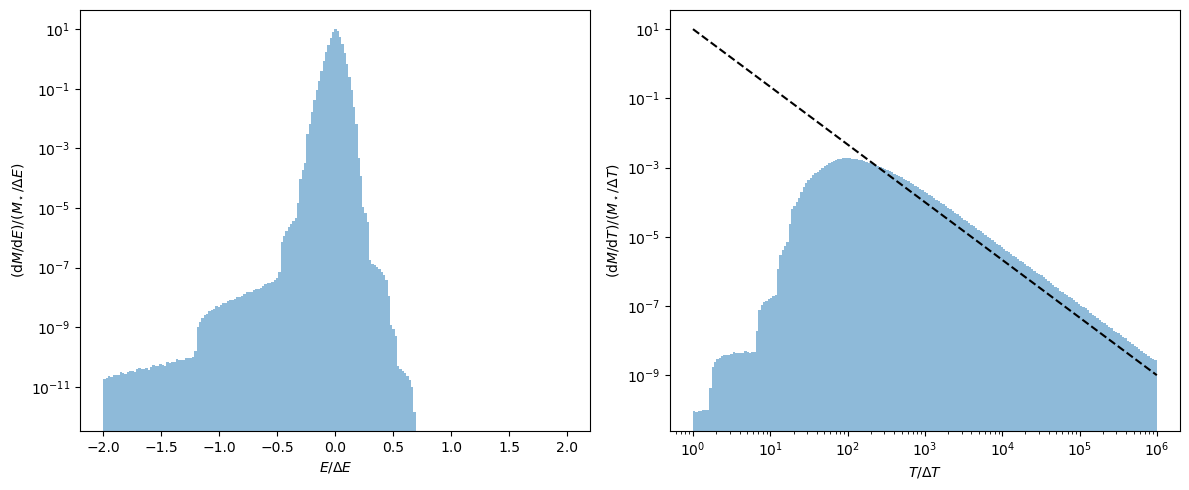

In [129]:
calc1 = TDECalculator('MAMS8Msun', orbit="kr", MBH=1e6, Rp=5.694, a=0.92, N=1500)
whole_star_sample1 = calc1.whole_star_sample(N_Omega=300**2)

plot_dist(calc1)
energy_plots(whole_star_sample1)

In [136]:
calc2 = TDECalculator('MAMS8Msun', orbit="kp", MBH=1e6, Rp=2.96, a=0.50, N=1500)
whole_star_sample2 = calc2.whole_star_sample(N_Omega=300**2)

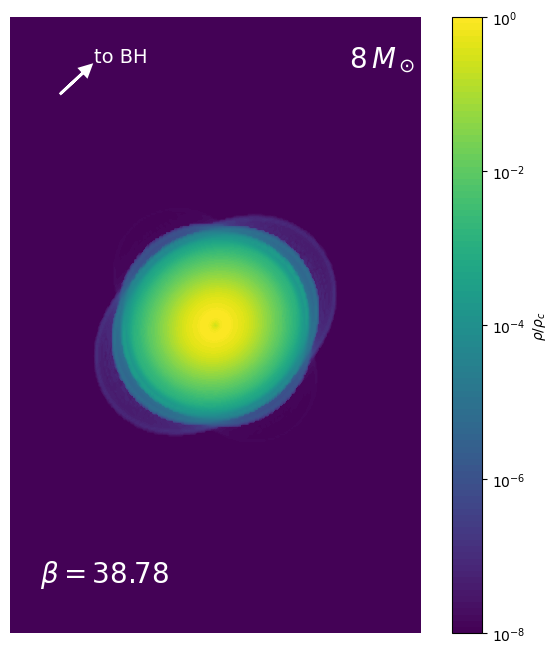

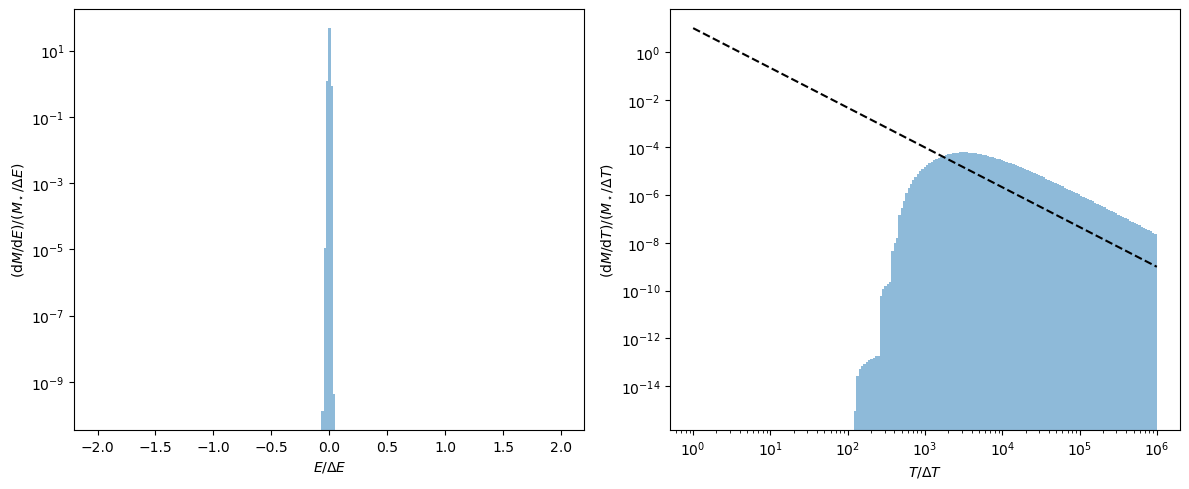

In [137]:
plot_dist(calc2)
energy_plots(whole_star_sample2)

## Graph Recreation ##

In [56]:
def plotter(t, tau, r, phi, label):
    x = r(tau) * np.cos(phi(tau))
    y = r(tau) * np.sin(phi(tau))

    plt.figure(figsize=(6, 6))
    plt.plot(0, 0, 'ko', label='Black Hole')
    plt.gca().add_artist(plt.Circle((0, 0), 2, color='k', alpha=0.3))
    plt.plot(x, y, label=label)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid()
    plt.axis("equal")
    plt.legend()
    plt.title("Parabolic Orbit")
    plt.show()

    plt.figure(figsize=(22,4))

    plt.subplot(1,3,1)
    plt.plot(tau, t(tau))
    plt.xlabel("τ")
    plt.ylabel("t(τ)")

    plt.subplot(1,3,2)
    plt.plot(tau, r(tau))
    plt.xlabel("τ")
    plt.ylabel("r(τ)")

    plt.subplot(1,3,3)
    plt.plot(tau, phi(tau))
    plt.xlabel("τ")
    plt.ylabel("ϕ(τ)")

    plt.show()


In [57]:
def compare_plotter(t, tau, r, phi, t2, tau2, r2, phi2, label1, label2):
    x = r(tau) * np.cos(phi(tau))
    y = r(tau) * np.sin(phi(tau))

    x2 = r2(tau2) * np.cos(phi2(tau2))
    y2 = r2(tau2) * np.sin(phi2(tau2))

    plt.figure(figsize=(6, 6))
    plt.plot(0, 0, 'ko', label='Black Hole')
    plt.gca().add_artist(plt.Circle((0, 0), 2, color='k', alpha=0.3))
    plt.plot(x, y, label=label1)
    plt.plot(x2, y2, label=label2)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid()
    plt.axis("equal")
    plt.legend()
    plt.title("Parabolic Orbits")
    plt.show()

    plt.figure(figsize=(22,4))

    plt.subplot(1,3,1)
    plt.plot(tau, t(tau), label=label1)
    plt.plot(tau2, t2(tau2), label=label2)
    plt.xlabel("τ")
    plt.ylabel("t(τ)")

    plt.subplot(1,3,2)
    plt.plot(tau, r(tau), label=label1)
    plt.plot(tau2, r2(tau2), label=label2)
    plt.xlabel("τ")
    plt.ylabel("r(τ)")

    plt.subplot(1,3,3)
    plt.plot(tau, phi(tau), label=label1)
    plt.plot(tau2, phi2(tau2), label=label2)
    plt.xlabel("τ")
    plt.ylabel("ϕ(τ)")

    plt.show()

In [58]:
calc._compute_schwartz_orbit()

t3 = calc.obs_t
tau3 = calc.t
r3 = calc.R
phi3 = calc.Phi

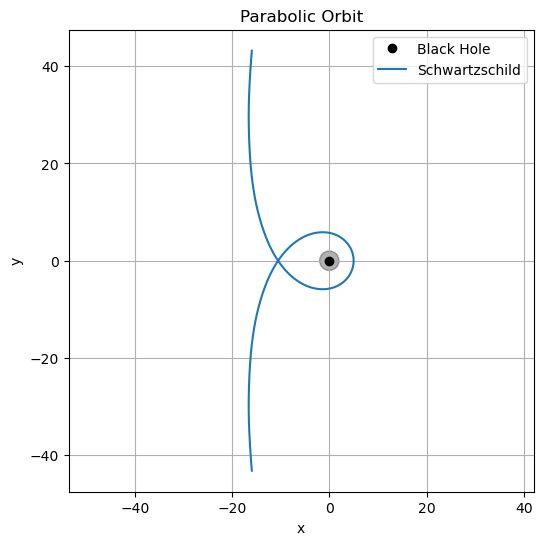

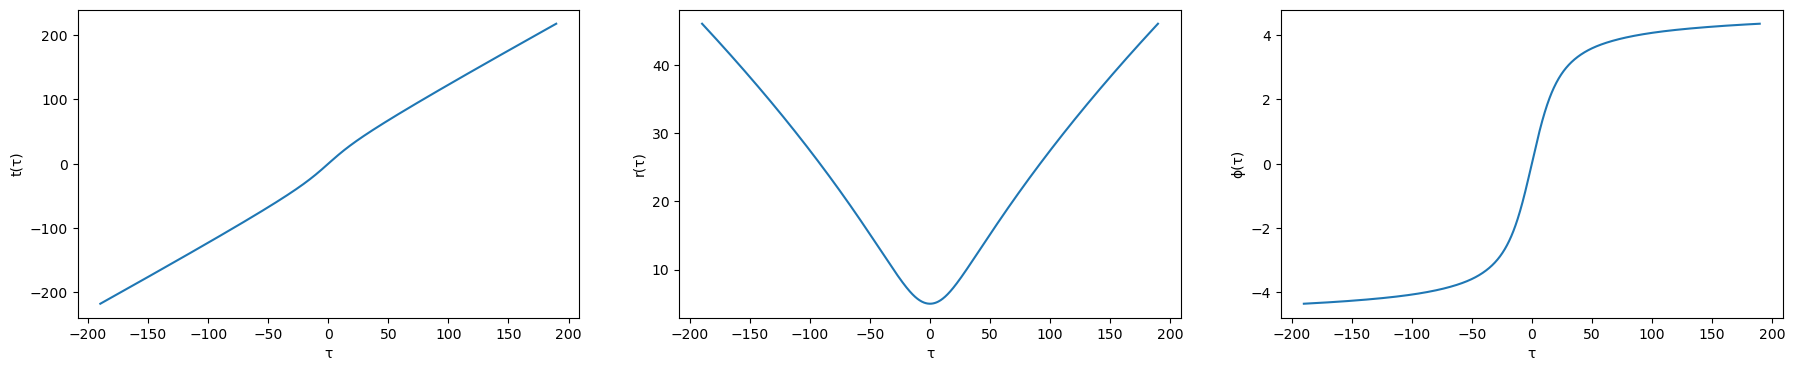

In [ ]:
plotter(t3, tau3, r3, phi3, "Schwartzschild")

## Kerr Prograde ##

In [60]:
calc._compute_kerr_orbit(prograde=True)

t = calc.obs_t
tau = calc.t
r = calc.R
phi = calc.Phi

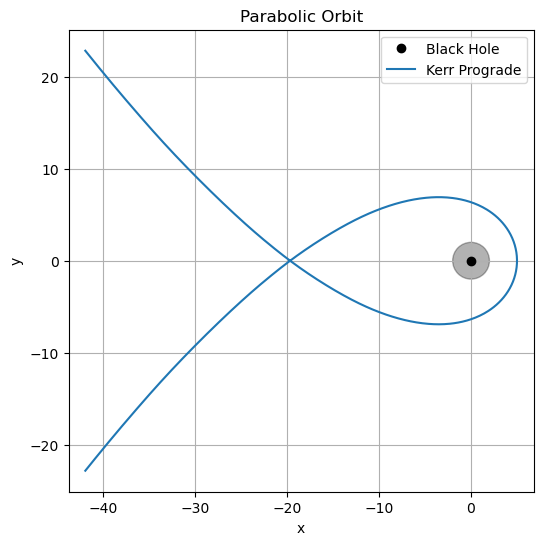

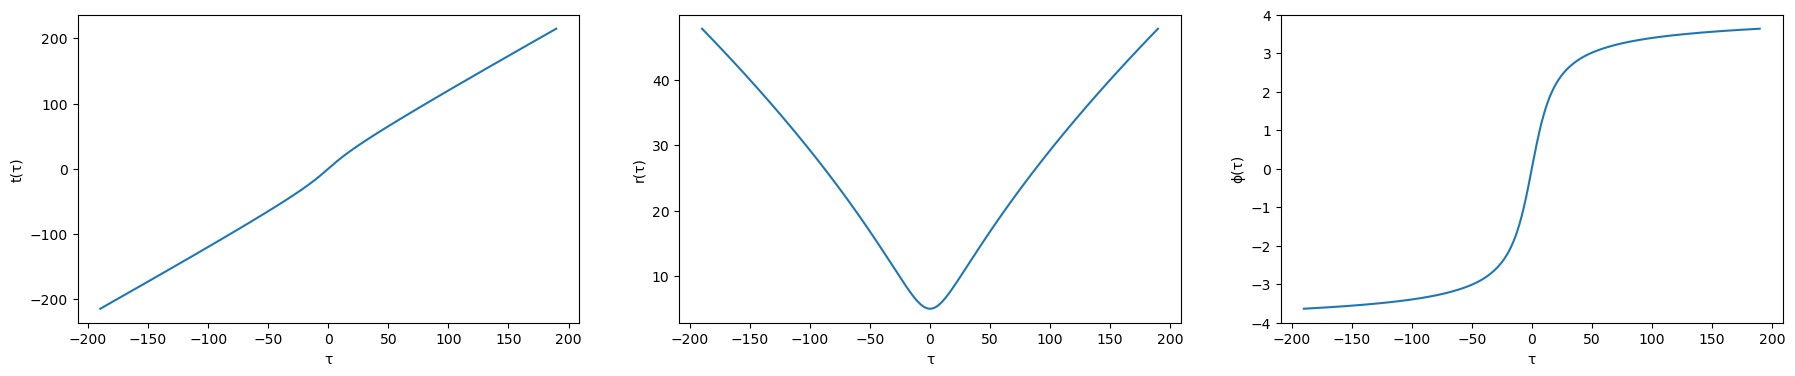

In [61]:
plotter(t, tau, r, phi, "Kerr Prograde")

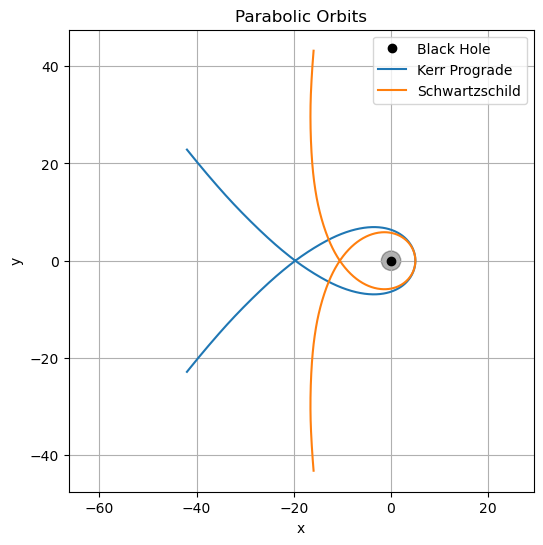

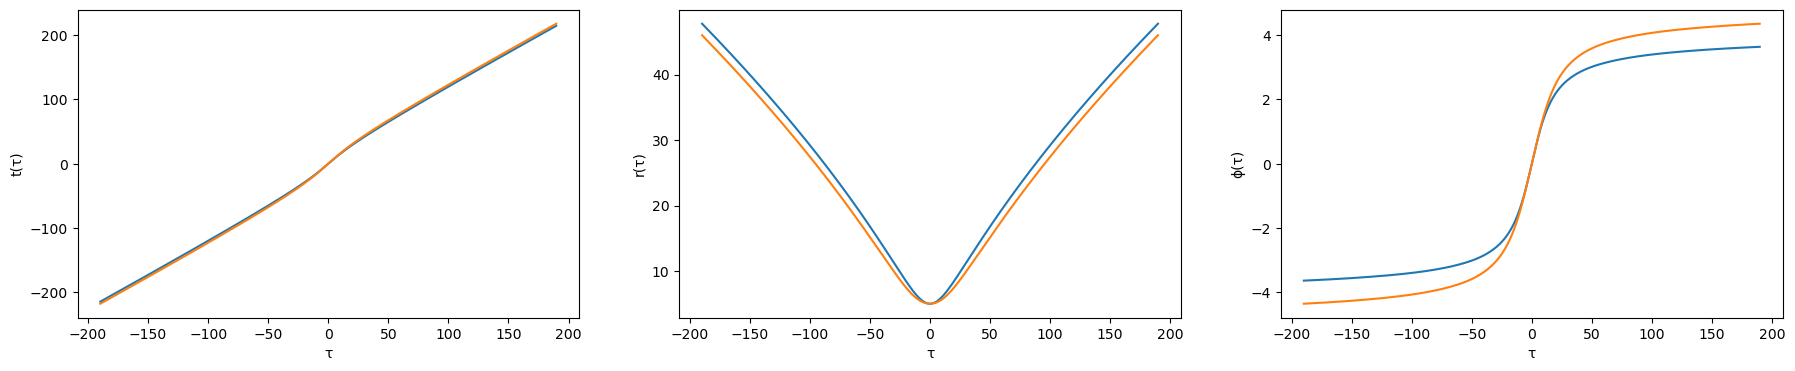

In [62]:
compare_plotter(t, tau, r, phi, t3, tau3, r3, phi3, "Kerr Prograde", "Schwartzschild")

## Kerr Retrograde ##

In [63]:
calc._compute_kerr_orbit(prograde=False)

t2 = calc.obs_t
tau2 = calc.t
r2 = calc.R
phi2 = calc.Phi

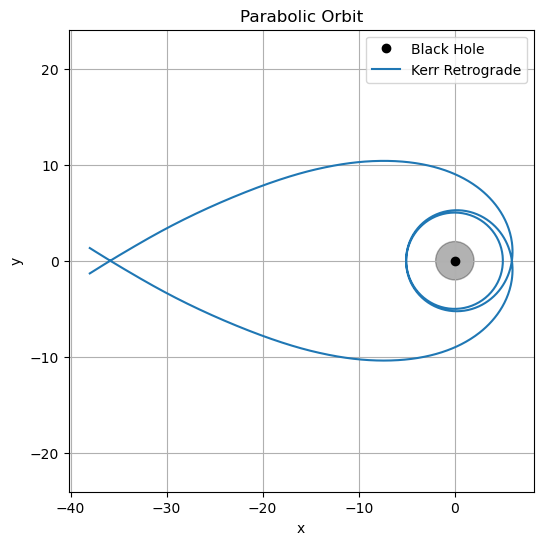

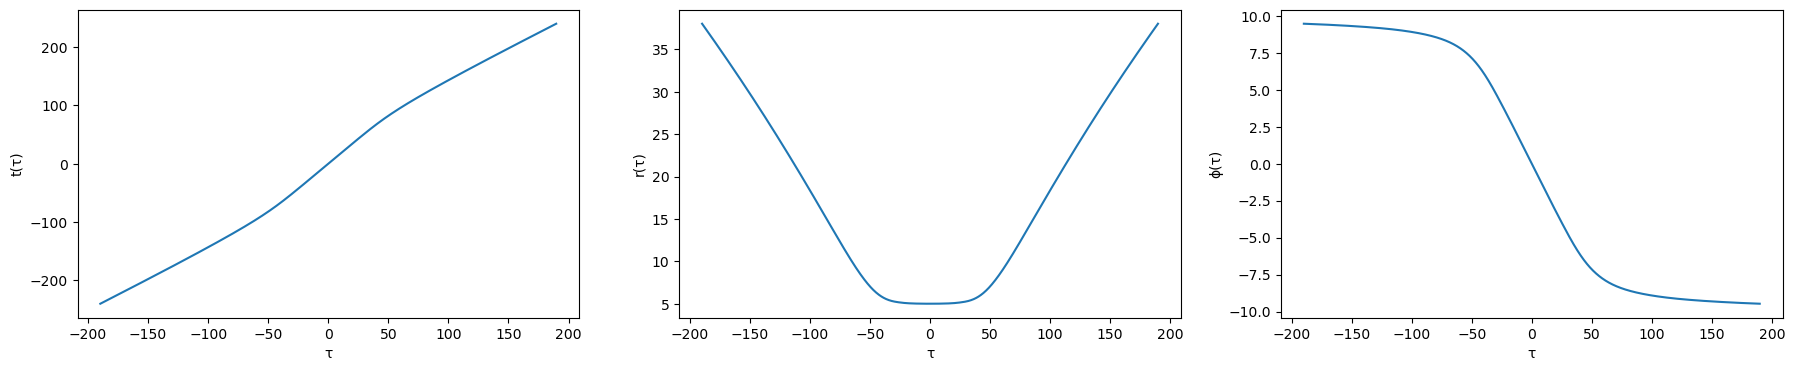

In [ ]:
plotter(t2, tau2, r2, phi2, "Kerr Retrograde")

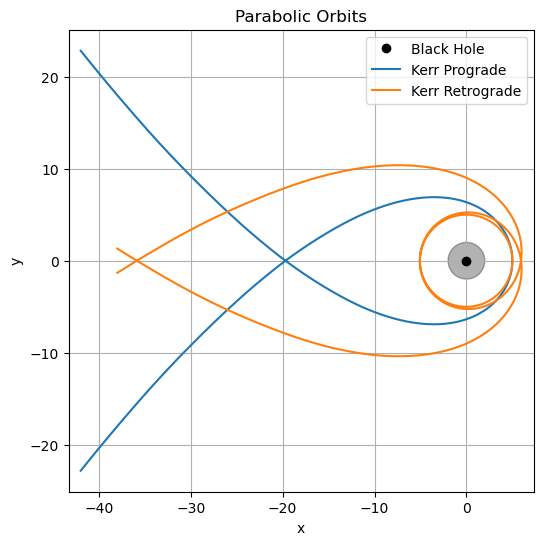

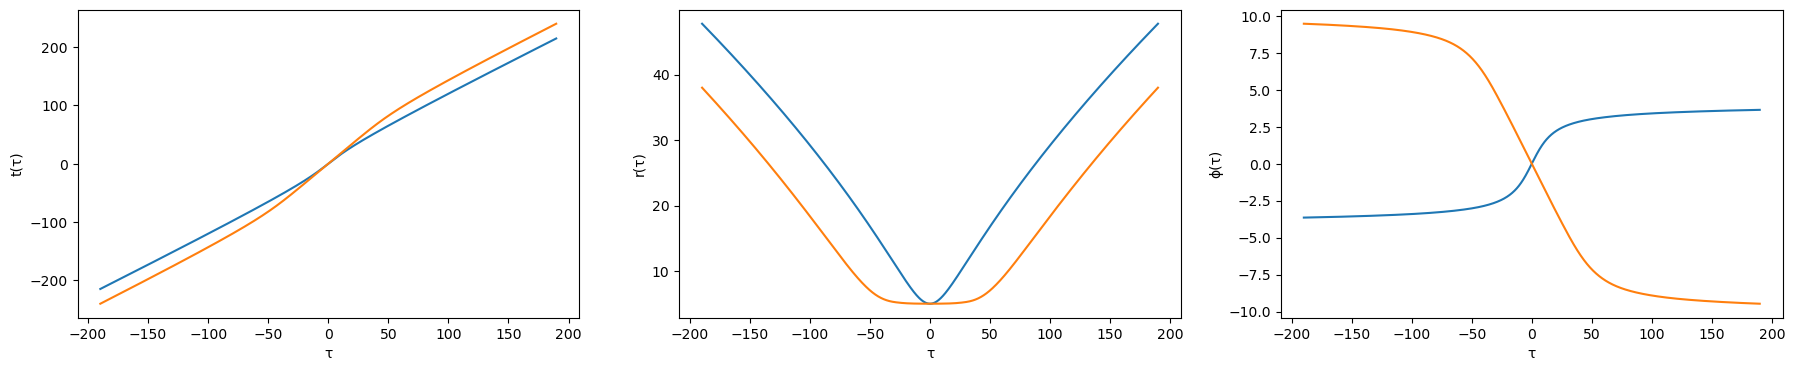

In [65]:
compare_plotter(t, tau, r, phi, t2, tau2, r2, phi2, "Kerr Prograde", "Kerr Retrograde")

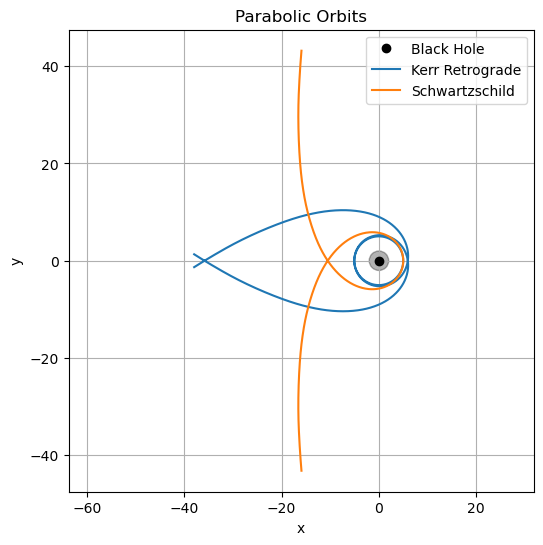

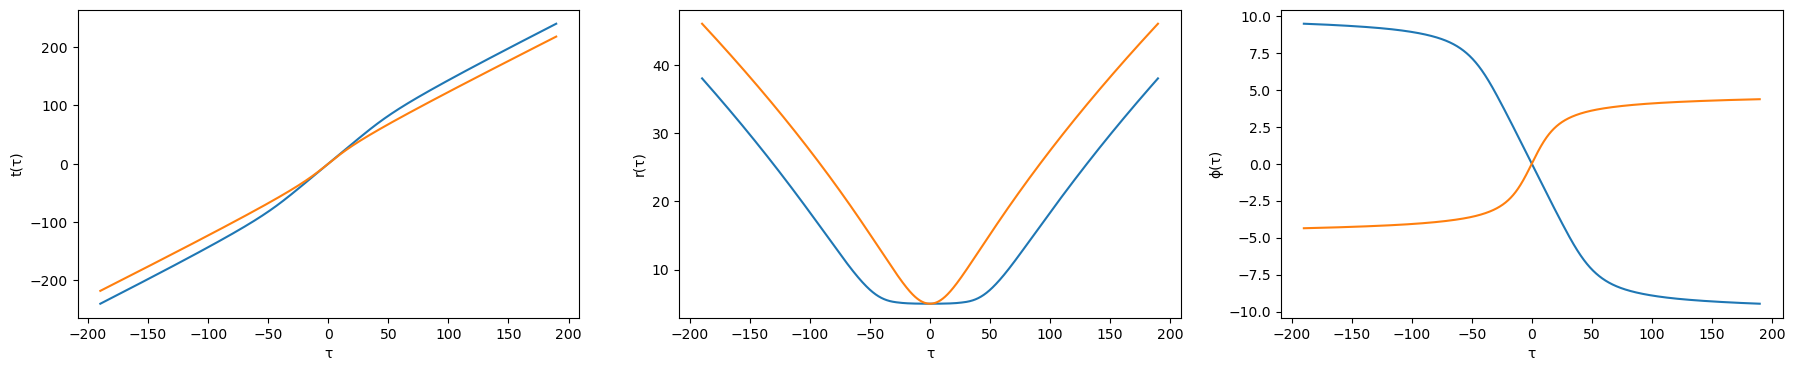

In [66]:
compare_plotter(t2, tau2, r2, phi2, t3, tau3, r3, phi3, "Kerr Retrograde", "Schwartzschild")